# CREDIT-WISE LOAN APPROVAL System

# Import Libraries & Packages

In [1]:
# Importing Python Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing Sklearn Packages
from sklearn.impute import SimpleImputer # Replaces Missing Values
from sklearn.preprocessing import LabelEncoder, OneHotEncoder # Data Enconding

from sklearn.model_selection import train_test_split # Train-Test-Split
from sklearn.preprocessing import StandardScaler # Data Scaling

from sklearn.linear_model import LogisticRegression # Logistic Regression
from sklearn.neighbors import KNeighborsClassifier # KNN (K Nearest Neighbours)
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Evaluation Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report # Evaluation Metrics

# Load the Dataset

In [2]:
# Loading Dataset
df = pd.read_csv("loan_approval_data.csv")

#### Collect Basic Info

In [3]:
# Collect Basic Info
df.shape
df.info()
df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
92,93.0,12965.0,9650.0,Salaried,29.0,Single,3.0,797.0,1.0,0.14,3770.0,11825.0,3368.0,60.0,Business,Urban,Graduate,Female,Private,Yes
942,943.0,7797.0,1884.0,Salaried,21.0,Married,3.0,559.0,0.0,0.18,17675.0,37924.0,NaN,12.0,Education,Urban,Graduate,Female,Private,No
204,205.0,6499.0,7511.0,Salaried,36.0,Married,0.0,NaN,1.0,0.20,2239.0,43907.0,17191.0,12.0,Education,NaN,Graduate,Male,MNC,Yes
666,NaN,13479.0,3230.0,Salaried,49.0,Single,0.0,553.0,1.0,0.38,2723.0,22082.0,1497.0,24.0,Home,NaN,Graduate,Female,Unemployed,No
103,104.0,19868.0,329.0,Contract,50.0,Married,2.0,747.0,0.0,0.22,16279.0,8065.0,18993.0,12.0,Education,Urban,Graduate,Female,Unemployed,Yes


# Data Cleaning & Pre-processing

#### 1. Check Missing Values

In [4]:
# Check Missing Values
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_%": ((df.isnull().sum())/len(df))*100
})

missing_val = missing[missing["missing_count"]>0]

print("No missing values found!") if missing_val.empty else missing_val

,missing_count,missing_%
Applicant_ID,50,5.0
Applicant_Income,50,5.0
Coapplicant_Income,50,5.0
Employment_Status,50,5.0
Age,50,5.0
Marital_Status,50,5.0
Dependents,50,5.0
Credit_Score,50,5.0
Existing_Loans,50,5.0
DTI_Ratio,50,5.0


#### 2. Check Duplicate Values

In [5]:
# Check Duplicate Values
duplicates = df.duplicated().sum()

if duplicates > 0:
    duplicate_rows = df[df.duplicated()]
    print(duplicate_rows)
    df.drop_duplicates()
    print("New Shape:", df.shape)
else:
    print("No duplicates found!")

No duplicates found!


#### 3. Inspect Data Inconsistency

In [6]:
# Inspect Data Inconsistency
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

#### 4. Fix Column Names & Column Data

In [7]:
# Fix Column Names & Column Data
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip()

#### 5. Handle Missing Values

In [8]:
# Handle Missing values
categorical_cols = df.select_dtypes(include="object").columns
numerical_cols = df.select_dtypes(include="number").columns

num_imp = SimpleImputer(strategy="mean") # Replacing missing values with mean values
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

cat_imp = SimpleImputer(strategy="most_frequent") # Replacing missing values with most frequently occuring values
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

#### 6. Identify Unique Values in Categorical Columns

In [9]:
# Identify Unique Values in Categorical Columns
for col in df.select_dtypes(include="object"):
    print("Column:", col)
    print("Unique Values:", df[col].nunique())
    print(df[col].value_counts(normalize=True)*100)
    print("*"*127)

Column: Employment_Status
Unique Values: 4
Employment_Status
Salaried         51.5
Contract         21.3
Self-employed    18.2
Unemployed        9.0
Name: proportion, dtype: float64
*******************************************************************************************************************************
Column: Marital_Status
Unique Values: 2
Marital_Status
Married    64.3
Single     35.7
Name: proportion, dtype: float64
*******************************************************************************************************************************
Column: Loan_Purpose
Unique Values: 5
Loan_Purpose
Business     25.2
Car          19.9
Home         19.0
Education    18.1
Personal     17.8
Name: proportion, dtype: float64
*******************************************************************************************************************************
Column: Property_Area
Unique Values: 3
Property_Area
Urban        51.7
Rural        29.4
Semiurban    18.9
Name: proportion, dtype: float64


#### 7. Remove unnecessary Features

In [10]:
# Remove unnecessary Features
df.drop("Applicant_ID", axis=1, inplace=True)

#### 8. Get Summary of the Dataset

In [11]:
# Get Summary of the Dataset
df.describe()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,4933.339492,2868.563488,10.857445,1.077058,69.537662,1.370603,0.140683,5712.189236,13982.086562,11212.555805,23.630794
min,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,6857.000000,2701.250000,31.000000,1.000000,618.000000,1.000000,0.230000,4964.000000,13166.000000,10478.250000,24.000000
50%,10852.571579,5082.455789,39.971579,1.237368,676.033684,2.000000,0.347263,9940.452632,24802.792632,20522.825263,48.000000
75%,14973.250000,7452.750000,49.000000,2.000000,735.000000,3.000000,0.470000,14784.750000,36396.000000,29683.250000,72.000000
max,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# Exploratory Data Analysis

#### 1. Are the Classes balanced ?

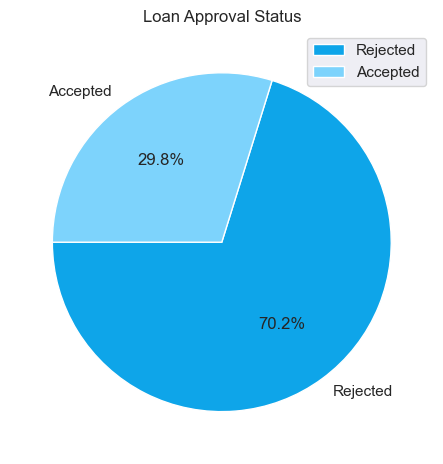

In [12]:
# Exploratory Data Analysis
# Are the classes balanced ?
sns.set_theme(style="dark")
fig, ax = plt.subplots()

loan_approval = df["Loan_Approved"].value_counts().reset_index()

ax.pie(
    loan_approval["count"],
    autopct = "%1.1f%%",
    labels = ["Rejected", "Accepted"],
    colors = ["#0EA5E9", "#7DD3FC"],
    startangle = 180
)

ax.set_title("Loan Approval Status")
ax.legend()
fig.tight_layout()
plt.show()

#### 2. Category-wise Analysis

***A. Employer_Category & Employment_Status***

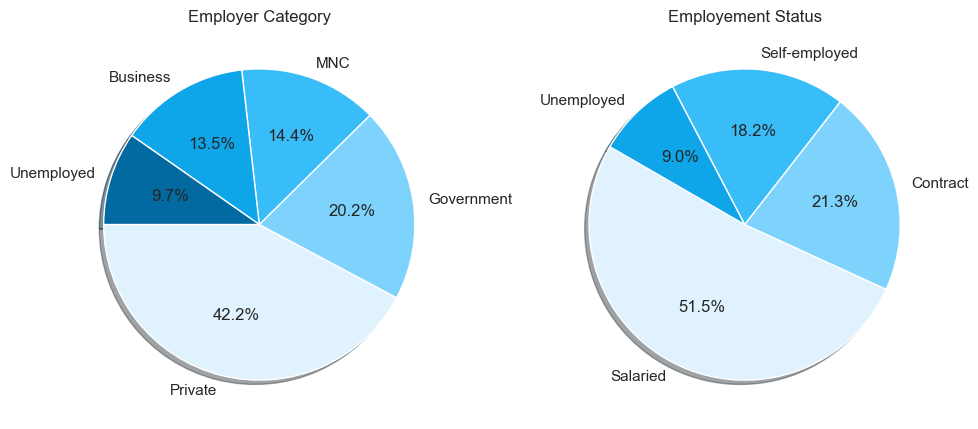

In [13]:
# Category-wise Analysis
# A. Employer_Category & Employment_Status
employer_category = df["Employer_Category"].value_counts().reset_index()
employment_status = df["Employment_Status"].value_counts().reset_index()

sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(1,2, figsize=(10,8))

custom_colors = ["#E0F2FE", "#7DD3FC", "#38BDF8", "#0EA5E9", "#0369A1"]


ax[0].pie(
    employer_category["count"],
    autopct = "%1.1f%%",
    labels = employer_category["Employer_Category"],
    colors = custom_colors,
    startangle = 180,
    shadow = True
)
ax[0].set_title("Employer Category")

ax[1].pie(
    employment_status["count"],
    autopct = "%1.1f%%",
    labels = employment_status["Employment_Status"],
    colors = custom_colors,
    startangle = 150,
    shadow = True
)
ax[1].set_title("Employement Status")

fig.tight_layout()
plt.show()

***B. Gender & Marital_Status***

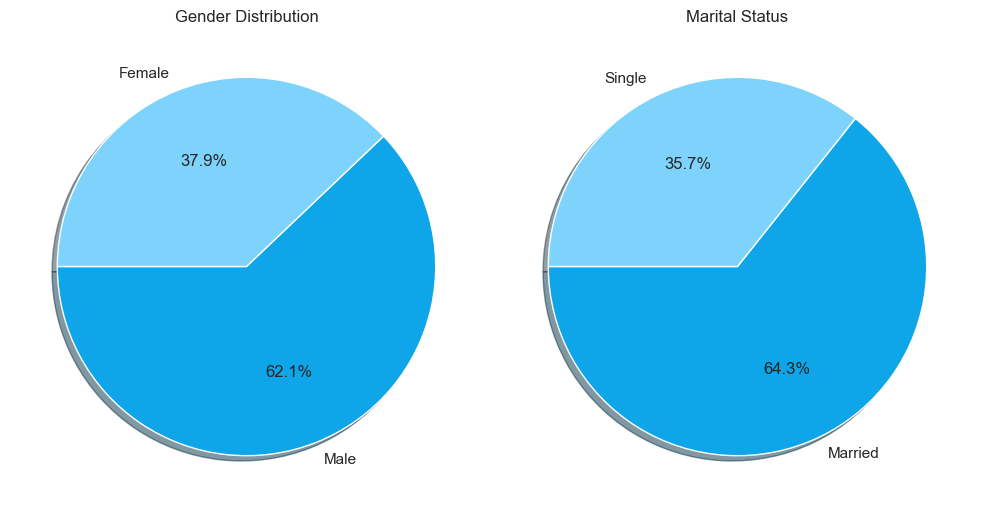

In [14]:
# B. Gender & Marital_Status
gender = df["Gender"].value_counts().reset_index()
marital_status = df["Marital_Status"].value_counts().reset_index()

sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(1,2, figsize=(10,8))

ax[0].pie(
    gender["count"],
    autopct = "%1.1f%%",
    labels = gender["Gender"],
    colors = ["#0EA5E9", "#7DD3FC"],
    startangle = 180,
    shadow = True
)
ax[0].set_title("Gender Distribution")

ax[1].pie(
    marital_status["count"],
    autopct = "%1.1f%%",
    labels = marital_status["Marital_Status"],
    colors = ["#0EA5E9", "#7DD3FC"],
    startangle = 180,
    shadow = True
)
ax[1].set_title("Marital Status")

fig.tight_layout()
plt.show()

***C. Loan_Purpose & Education_Level***

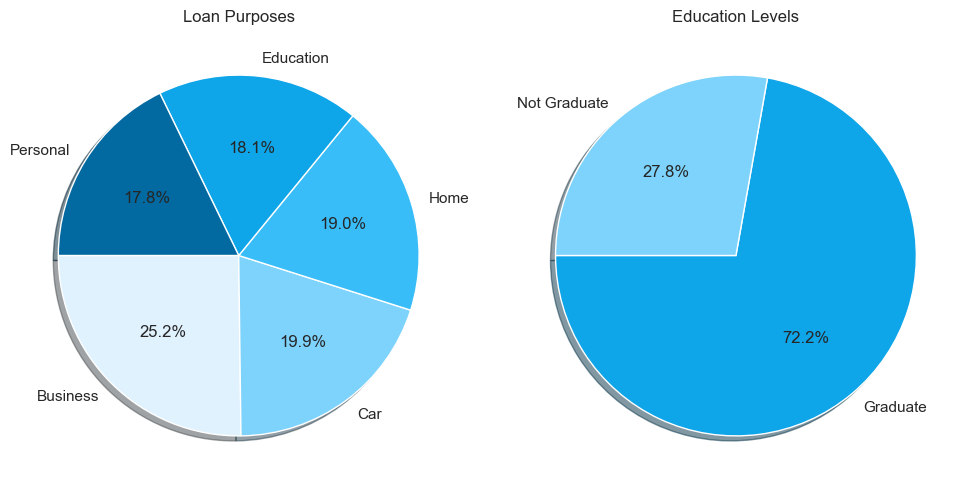

In [15]:
# C. Loan_Purpose & Education_Level
loan_purpose = df["Loan_Purpose"].value_counts().reset_index()
education_level = df["Education_Level"].value_counts().reset_index()

sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(1,2, figsize=(10,8))

custom_colors = ["#E0F2FE", "#7DD3FC", "#38BDF8", "#0EA5E9", "#0369A1"]

ax[0].pie(
    loan_purpose["count"],
    autopct = "%1.1f%%",
    labels = loan_purpose["Loan_Purpose"],
    colors = custom_colors,
    startangle = 180,
    shadow = True
)
ax[0].set_title("Loan Purposes")

ax[1].pie(
    education_level["count"],
    autopct = "%1.1f%%",
    labels = education_level["Education_Level"],
    colors = ["#0EA5E9", "#7DD3FC"],
    startangle = 180,
    shadow = True
)
ax[1].set_title("Education Levels")

fig.tight_layout()
plt.show()

#### 3. Applicant Income Analysis

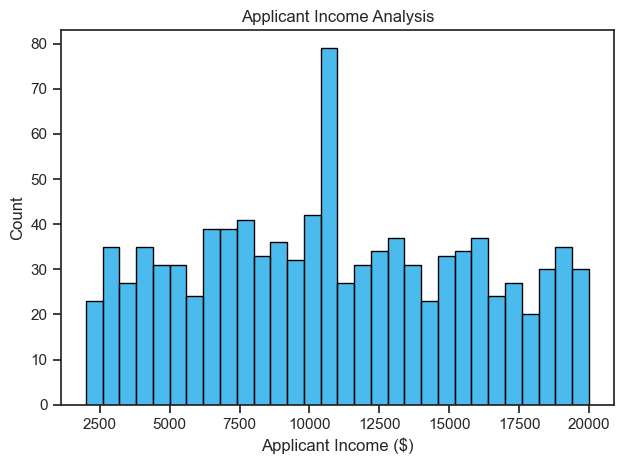

In [16]:
# Applicant Income Analysis
sns.set_theme(style="ticks")
fig, ax = plt.subplots()

sns.histplot(
    x = df["Applicant_Income"],
    edgecolor = "black",
    color = "#0EA5E9",
    bins = 30,
    ax = ax
)

plt.title("Applicant Income Analysis")
ax.set_xlabel("Applicant Income ($)")
fig.tight_layout()
plt.show()

#### 4. Co-Applicant Income Analysis

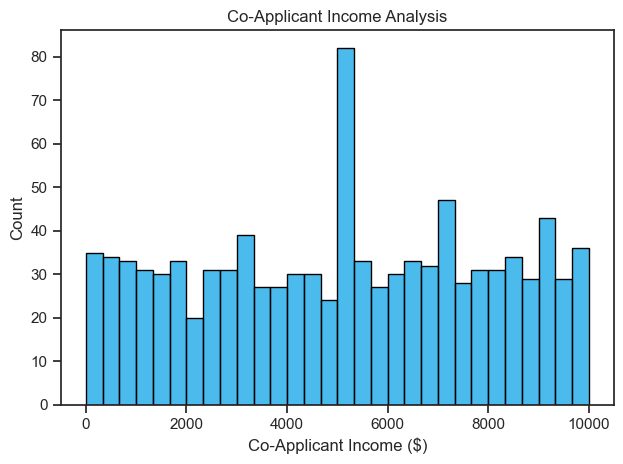

In [17]:
# Co-Applicant Income Analysis
sns.set_theme(style="ticks")
fig, ax = plt.subplots()

sns.histplot(
    x = df["Coapplicant_Income"],
    edgecolor = "black",
    color = "#0EA5E9",
    bins = 30,
    ax = ax
)

plt.title("Co-Applicant Income Analysis")
ax.set_xlabel("Co-Applicant Income ($)")
fig.tight_layout()
plt.show()

#### 5. Outliers Detection with Box Plots

***A. Financial Profile of Applicants by Loan Approval Status***

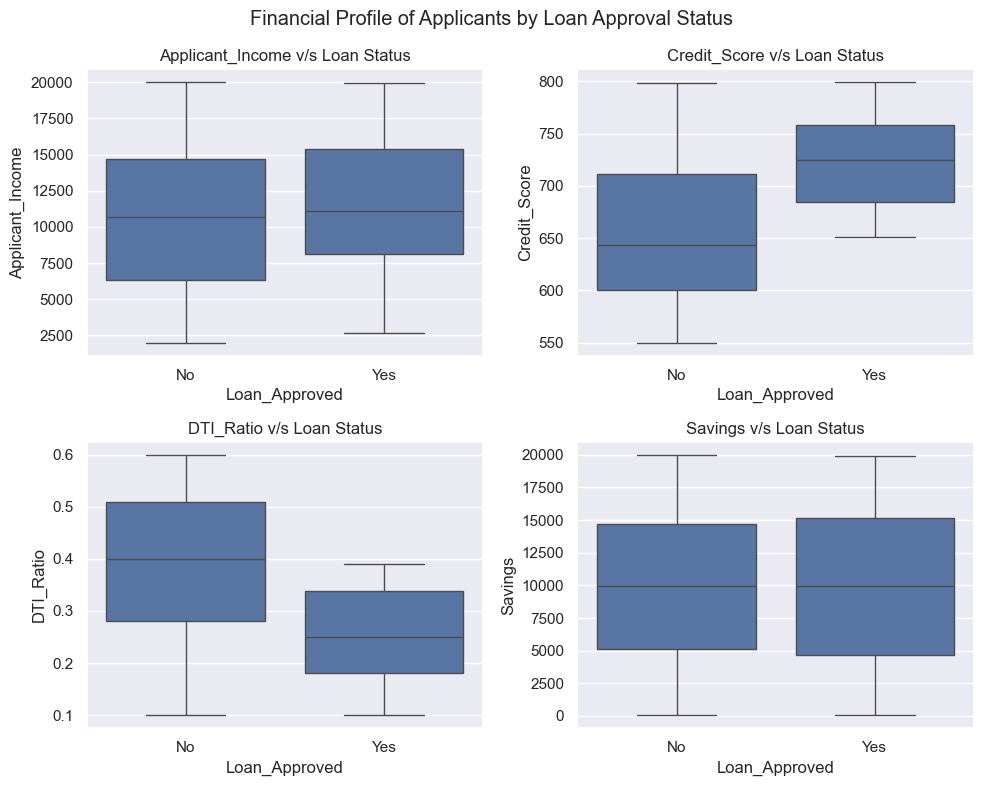

In [18]:
# Outliers Detection with Box Plots
# A. Financial Profile of Applicants by Loan Approval Status
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(2,2, figsize = (10,8))

sns.boxplot(ax = ax[0,0], x = df["Loan_Approved"], y = df["Applicant_Income"])
sns.boxplot(ax = ax[0,1], x = df["Loan_Approved"], y = df["Credit_Score"])
sns.boxplot(ax = ax[1,0], x = df["Loan_Approved"], y = df["DTI_Ratio"])
sns.boxplot(ax = ax[1,1], x = df["Loan_Approved"], y = df["Savings"])

fig.suptitle("Financial Profile of Applicants by Loan Approval Status")
             
ax[0,0].set_title("Applicant_Income v/s Loan Status")
ax[0,1].set_title("Credit_Score v/s Loan Status")
ax[1,0].set_title("DTI_Ratio v/s Loan Status")
ax[1,1].set_title("Savings v/s Loan Status")

fig.tight_layout()
plt.show()

#### 6. Credit Score Analysis against Loan Approval Status

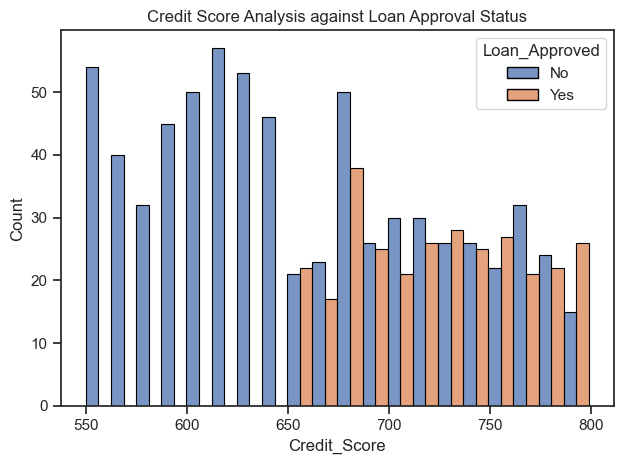

In [19]:
# Credit Score Analysis against Loan Approval Status
sns.set_theme(style="ticks")
fig, ax = plt.subplots()

sns.histplot(
    x = df["Credit_Score"],
    hue = df["Loan_Approved"],
   edgecolor = "black",
    bins = 20,
    multiple = "dodge",
    ax = ax
)

plt.title("Credit Score Analysis against Loan Approval Status")
fig.tight_layout()
plt.show()

#### 7. Applicant Income Analysis against Loan Approval Status

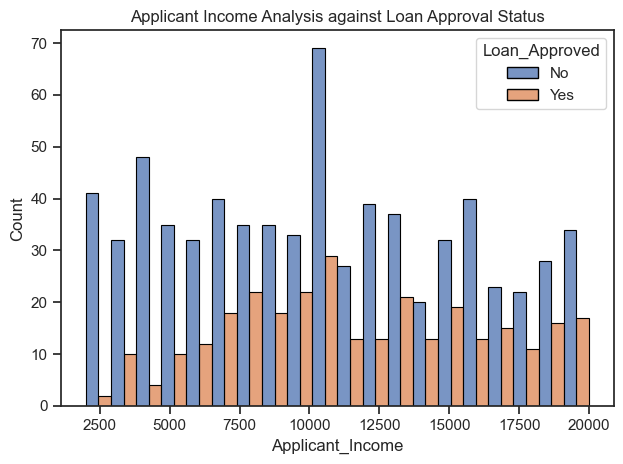

In [20]:
# Applicant Income Analysis against Loan Approval Status
sns.set_theme(style="ticks")
fig, ax = plt.subplots()

sns.histplot(
    x = df["Applicant_Income"],
    hue = df["Loan_Approved"],
    edgecolor = "black",
    bins = 20,
    multiple = "dodge",
    ax = ax
)

plt.title("Applicant Income Analysis against Loan Approval Status")
fig.tight_layout()
plt.show()

#### 8. Correlation Heatmap

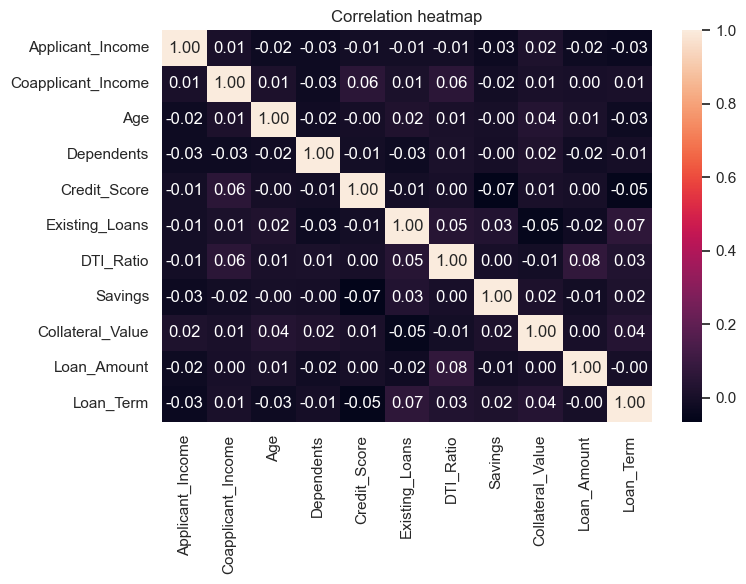

In [21]:
# Correlation Heatmap
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

sns.set_theme(style="dark")
fig, ax = plt.subplots(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    ax = ax
)

plt.title("Correlation heatmap")
fig.tight_layout()
plt.show()

# Feature Engineering

#### 1. Data Encoding

***A. Encoding Output***

In [22]:
# Feature Engineering
# Data Encoding
# A. Encoding Output
le = LabelEncoder()
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

***B. Encoding Input Features***

In [23]:
# B. Encoding Input Features
cols=["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Education_Level", "Gender", "Employer_Category"]

ohe = OneHotEncoder(
    drop = "first", # Avoid Dummy Variable Trap
    sparse_output = False, # Get both zero & non-zero values
    handle_unknown = "ignore" # Encodes unknown data in testing dataset, which was not seen in training dataset
)
encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)
df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

#### 2. Determine Collinearity

In [24]:
# Determine Collinearity
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

# Collinearity w.r.t. Loan_Approved
corr_matrix["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level_Not Graduate    

# Train-Test-Split

In [25]:
# Train-Test-Split
X = df.drop(columns=["Loan_Approved"])
y = df["Loan_Approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Education_Level_Not Graduate,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


# Feature Scaling

In [26]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Machine Learning

#### 1. Logistic Regression

***Model Training***

In [27]:
# 1. Logistic Regression
# Model Training
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)

***Model Evaluation***

In [28]:
# Model Evaluation - Logistic Regression
lr_accuracy = accuracy_score(y_test, y_pred)*100
lr_precision = precision_score(y_test, y_pred)*100
lr_recall = recall_score(y_test, y_pred)*100
lr_f1 = f1_score(y_test, y_pred)*100

print("Logistic Regression Model")
print(f"Accuracy: {lr_accuracy:.3f} %")
print(f"Precision: {lr_precision:.3f} %")
print(f"Recall: {lr_recall:.3f} %")
print(f"f1-score: {lr_f1:.3f} %")

Logistic Regression Model
Accuracy: 86.500 %
Precision: 78.333 %
Recall: 77.049 %
f1-score: 77.686 %


#### 2. KNN (K Nearest Neighbours)

***Model Training***

In [29]:
# 2. KNN (K Nearest Neighbours)
# Model Training
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

***Model Evaluation***

In [30]:
# Model Evaluation - KNN (K Nearest Neighbours)
knn_accuracy = accuracy_score(y_test, y_pred)*100
knn_precision = precision_score(y_test, y_pred)*100
knn_recall = recall_score(y_test, y_pred)*100
knn_f1 = f1_score(y_test, y_pred)*100

print("KNN (K Nearest Neighbours) Model")
print(f"Accuracy: {knn_accuracy:.3f} %")
print(f"Precision: {knn_precision:.3f} %")
print(f"Recall: {knn_recall:.3f} %")
print(f"f1-score: {knn_f1:.3f} %")

KNN (K Nearest Neighbours) Model
Accuracy: 76.000 %
Precision: 62.745 %
Recall: 52.459 %
f1-score: 57.143 %


#### 3. Gaussian Naive Bayes Algorithm

***Model Training***

In [31]:
# 3. Gaussian Naive Bayes
# Model Training
bayes_model = GaussianNB()
bayes_model.fit(X_train_scaled, y_train)
y_pred = bayes_model.predict(X_test_scaled)

***Model Evaluation***

In [32]:
# Model Evaluation - Gaussian Naive Bayes Algorithm
bayes_accuracy = accuracy_score(y_test, y_pred)*100
bayes_precision = precision_score(y_test, y_pred)*100
bayes_recall = recall_score(y_test, y_pred)*100
bayes_f1 = f1_score(y_test, y_pred)*100

print("Gaussian Naive Bayes Model")
print(f"Accuracy: {bayes_accuracy:.3f} %")
print(f"Precision: {bayes_precision:.3f} %")
print(f"Recall: {bayes_recall:.3f} %")
print(f"f1-score: {bayes_f1:.3f} %")

Gaussian Naive Bayes Model
Accuracy: 86.500 %
Precision: 80.357 %
Recall: 73.770 %
f1-score: 76.923 %


#### Model Comparison

In [33]:
eval_df = pd.DataFrame(
    {
        "Accuracy": [lr_accuracy, knn_accuracy, bayes_accuracy],
        "Precision": [lr_precision, knn_precision, bayes_precision],
        "Recall": [lr_recall, knn_recall, bayes_recall],
        "F1 Score": [lr_f1, knn_f1, bayes_f1]
    }, index = ["Logistic Regression", "KNN", "Naive Bayes"]
)
eval_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,86.5,78.333333,77.049180,77.685950
KNN,76.0,62.745098,52.459016,57.142857
Naive Bayes,86.5,80.357143,73.770492,76.923077


#### Confusion Matrix

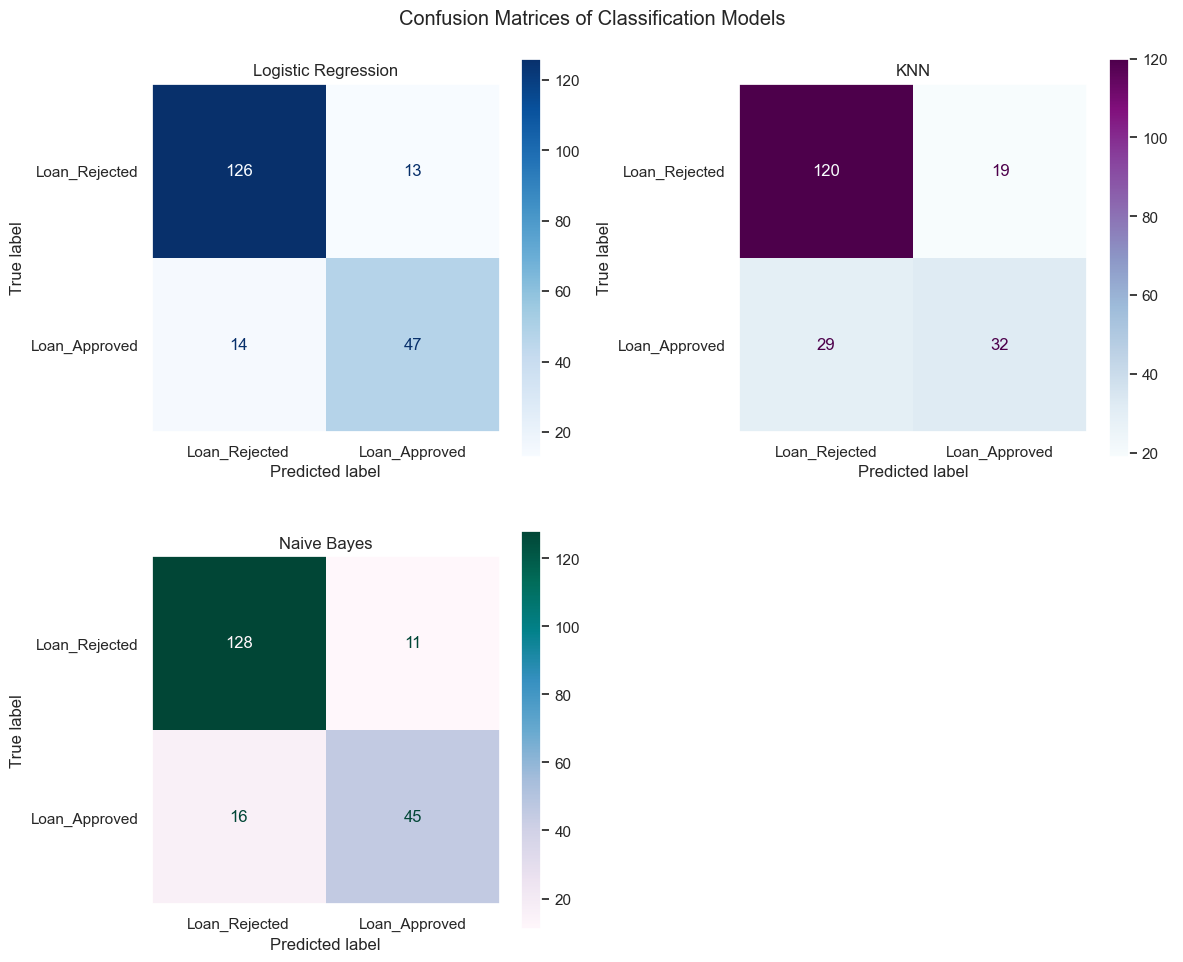

In [34]:
# Confusion Matrix
models = {
    "Logistic Regression": lr_model,
    "KNN": knn_model,
    "Naive Bayes": bayes_model
}
classes = ["Loan_Rejected", "Loan_Approved"]
cmaps = ["Blues", "BuPu", "PuBuGn"]

sns.set_theme(style="dark")
fig, ax = plt.subplots(2,2, figsize=(12,10))
axes = ax.ravel() # flatten 

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels = classes,
        cmap = cmaps[i],
        colorbar = True,
        ax = axes[i]
    )
    axes[i].set_title(name)
    
ax[1,1].axis("off")
plt.suptitle("Confusion Matrices of Classification Models")
fig.tight_layout()
plt.show()

## Conclusion: 
### Best Model => Naive Bayes
### - Maximum Precision Score
### - Minimum Type-I Error

# Feature Engineering

#### Add/Transform Features

In [35]:
# Feature Engineering
# Add/Transform Features
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2
# Squaring penalises heavily

df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])
# Log transformation helps to reduce skewness, as income incase of loans, is rightly heavily skewed
# Log transformation reduces the effect the outliers

# Train-Test-Split

In [36]:
# Train-Test-Split
X = df.drop(columns=["Loan_Approved"])
y = df["Loan_Approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Urban,Education_Level_Not Graduate,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq,Applicant_Income_log
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0121,363609.000000,8.681181
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0441,376996.000000,8.472196
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0484,341056.000000,9.292249
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.1156,527076.000000,7.776954
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0324,457021.542187,8.561975


# Feature Scaling

In [37]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Machine Learning

#### 1. Logistic Regression

***Model Training***

In [38]:
# 1. Logistic Regression
# Model Training
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)

***Model Evaluation***

In [39]:
# Model Evaluation - Logistic Regression
lr_accuracy = accuracy_score(y_test, y_pred)*100
lr_precision = precision_score(y_test, y_pred)*100
lr_recall = recall_score(y_test, y_pred)*100
lr_f1 = f1_score(y_test, y_pred)*100

print("Logistic Regression Model")
print(f"Accuracy: {lr_accuracy:.3f} %")
print(f"Precision: {lr_precision:.3f} %")
print(f"Recall: {lr_recall:.3f} %")
print(f"f1-score: {lr_f1:.3f} %")

Logistic Regression Model
Accuracy: 87.500 %
Precision: 79.032 %
Recall: 80.328 %
f1-score: 79.675 %


#### 2. KNN (K Nearest Neighbours)

***Model Training***

In [40]:
# 2. KNN (K Nearest Neighbours)
# Model Training
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

***Model Evaluation***

In [41]:
# Model Evaluation - KNN (K Nearest Neighbours)
knn_accuracy = accuracy_score(y_test, y_pred)*100
knn_precision = precision_score(y_test, y_pred)*100
knn_recall = recall_score(y_test, y_pred)*100
knn_f1 = f1_score(y_test, y_pred)*100

print("KNN (K Nearest Neighbours) Model")
print(f"Accuracy: {knn_accuracy:.3f} %")
print(f"Precision: {knn_precision:.3f} %")
print(f"Recall: {knn_recall:.3f} %")
print(f"f1-score: {knn_f1:.3f} %")

KNN (K Nearest Neighbours) Model
Accuracy: 83.500 %
Precision: 75.000 %
Recall: 68.852 %
f1-score: 71.795 %


#### 3. Gaussian Naive Bayes

***Model Training***

In [42]:
# 3. Gaussian Naive Bayes
# Model Training
bayes_model = GaussianNB()
bayes_model.fit(X_train_scaled, y_train)
y_pred = bayes_model.predict(X_test_scaled)

***Model Evaluation***

In [43]:
# Model Evaluation - Gaussian Naive Bayes Algorithm
bayes_accuracy = accuracy_score(y_test, y_pred)*100
bayes_precision = precision_score(y_test, y_pred)*100
bayes_recall = recall_score(y_test, y_pred)*100
bayes_f1 = f1_score(y_test, y_pred)*100

print("Gaussian Naive Bayes Model")
print(f"Accuracy: {bayes_accuracy:.3f} %")
print(f"Precision: {bayes_precision:.3f} %")
print(f"Recall: {bayes_recall:.3f} %")
print(f"f1-score: {bayes_f1:.3f} %")

Gaussian Naive Bayes Model
Accuracy: 91.000 %
Precision: 83.077 %
Recall: 88.525 %
f1-score: 85.714 %


#### Model Comparision

In [44]:
eval_df = pd.DataFrame(
    {
        "Accuracy": [lr_accuracy, knn_accuracy, bayes_accuracy],
        "Precision": [lr_precision, knn_precision, bayes_precision],
        "Recall": [lr_recall, knn_recall, bayes_recall],
        "F1 Score": [lr_f1, knn_f1, bayes_f1]
    }, index = ["Logistic Regression", "KNN", "Naive Bayes"]
)
eval_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,87.5,79.032258,80.327869,79.674797
KNN,83.5,75.000000,68.852459,71.794872
Naive Bayes,91.0,83.076923,88.524590,85.714286


#### Confusion Matrix

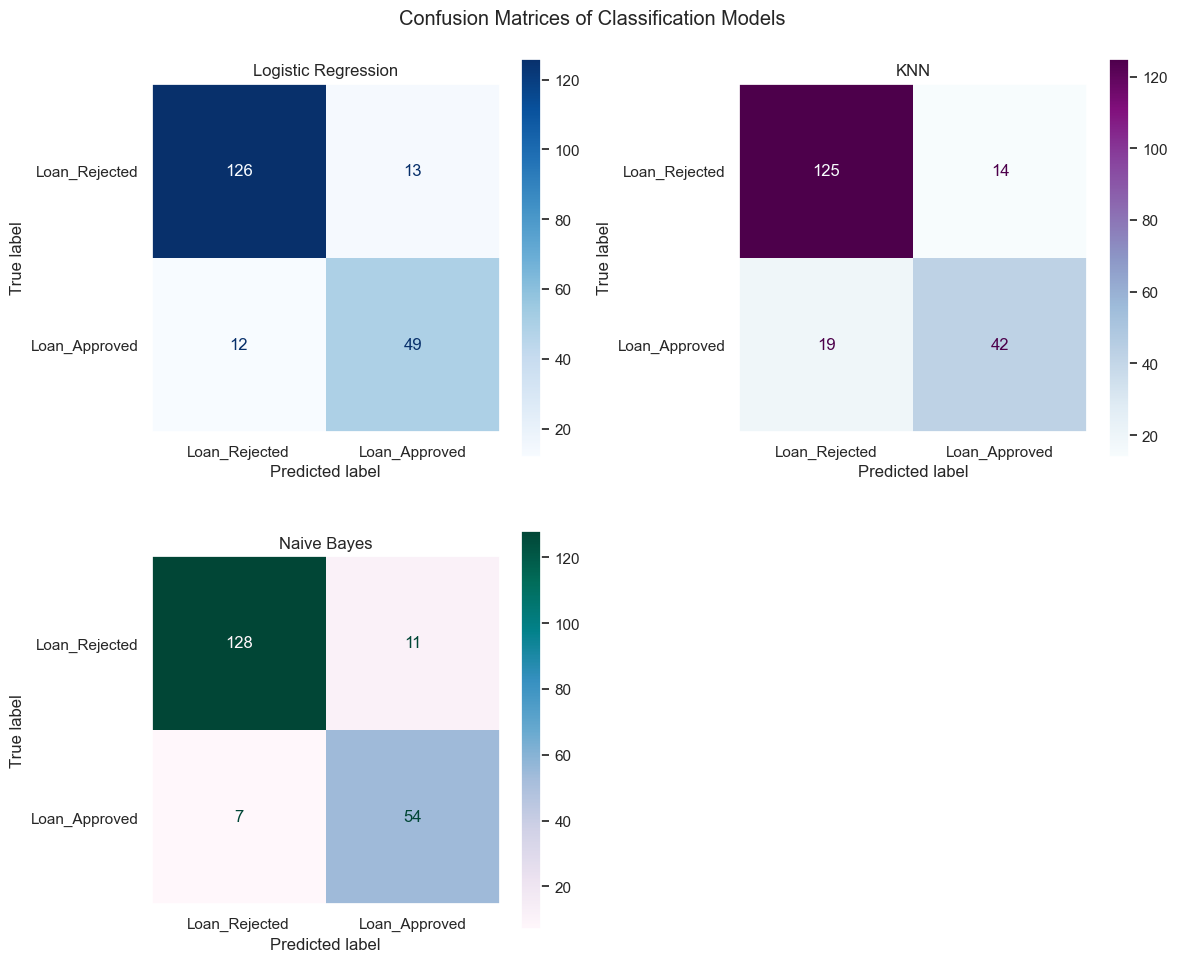

In [45]:
# Confusion Matrix
models = {
    "Logistic Regression": lr_model,
    "KNN": knn_model,
    "Naive Bayes": bayes_model
}
classes = ["Loan_Rejected", "Loan_Approved"]
cmaps = ["Blues", "BuPu", "PuBuGn"]

sns.set_theme(style="dark")
fig, ax = plt.subplots(2,2, figsize=(12,10))
axes = ax.ravel() # flatten 

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels = classes,
        cmap = cmaps[i],
        colorbar = True,
        ax = axes[i]
    )
    axes[i].set_title(name)
    
ax[1,1].axis("off")
plt.suptitle("Confusion Matrices of Classification Models")
fig.tight_layout()
plt.show()

## Conclusion: 
### Best Model => Naive Bayes
### - Maximum Accuracy Score
### - Maximum Precision Score
### - Maximum Recall Score
### - Maximum F1 Score